In [ ]:
#exercieXP

In [ ]:
#exercice1

In [20]:
import pandas as pd
import os


chemin_fichier = r"C:\Users\hp\Desktop\DI_BOOTCAMP\week2\Day2\train.csv"

# Charger le dataset local
df = pd.read_csv(chemin_fichier)


lignes_avant = df.shape[0]
print(f"Nombre de lignes avant suppression : {lignes_avant}")


nb_doublons = df.duplicated().sum()
print(f"Nombre de lignes en double détectées : {nb_doublons}")

# 3. Supprimer les doublons
df.drop_duplicates(inplace=True)


lignes_apres = df.shape[0]
print(f"Nombre de lignes après suppression : {lignes_apres}")
print(f"Total de lignes supprimées : {lignes_avant - lignes_apres}")


Nombre de lignes avant suppression : 891
Nombre de lignes en double détectées : 0
Nombre de lignes après suppression : 891
Total de lignes supprimées : 0


In [ ]:
#exercice 2 
import pandas as pd
import os
from sklearn.impute import SimpleImputer


# Afficher le compte des valeurs manquantes par colonne
print(df.isnull().sum())

# Supprime uniquement les lignes où 'Embarked' est vide
df.dropna(subset=['Embarked'], inplace=True)

# Calculer l'âge médian
age_median = df['Age'].median()

# Remplacer les valeurs manquantes par ce médian
df['Age'].fillna(age_median, inplace=True)
# Créer l'imputer avec une stratégie de valeur constante
imputer_constante = SimpleImputer(strategy='constant', fill_value='Inconnu')

# Appliquer l'imputer sur la colonne Cabin (nécessite un format double crochet [[]])
df[['Cabin']] = imputer_constante.fit_transform(df[['Cabin']])
# Vérification finale
print("Valeurs manquantes restantes :")
print(df[['Embarked', 'Age', 'Cabin']].isnull().sum())



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Valeurs manquantes restantes :
Embarked    0
Age         0
Cabin       0
dtype: int64


In [ ]:
#exercice 3

In [ ]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder


# Taille de la famille (Passager + Frères/Sœurs/Époux + Parents/Enfants)
df['FamilySize'] = 1 + df['SibSp'] + df['Parch']

# Extraction du titre à partir du nom (ex: "Braund, Mr. Owen Harris" -> "Mr")
# On découpe après la virgule, puis autour du point, et on nettoie les espaces
df['Title'] = df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

# Optionnel : Regrouper les titres rares pour simplifier l'apprentissage
titres_rares = ['Dr', 'Rev', 'Col', 'Major', 'Mlle', 'Ms', 'Mme', 'Capt', 'Lady', 'the Countess', 'Jonkheer', 'Don', 'Sir']
df['Title'] = df['Title'].replace(titres_rares, 'Rare')


# --- 2. Encodage des variables catégorielles en format numérique ---

# Option A : Encodage par étiquette (Label Encoding) pour la colonne 'Title'
# Idéal pour les colonnes avec plusieurs catégories distinctes

label_enc = LabelEncoder()
df['Title_Encoded'] = label_enc.fit_transform(df['Title'])

# Option B : Encodage One-Hot (One-Hot Encoding) pour la colonne 'Sex'
# Crée des colonnes de 0 et 1 (ex: 'Sex_male', 'Sex_female')
# C'est la méthode recommandée pour éviter que l'algorithme ne croie qu'une catégorie est "supérieure" à une autre
df = pd.get_dummies(df, columns=['Sex'], drop_first=True, dtype=int)


# --- 3. Aperçu du résultat ---
print(df[['Name', 'Title', 'Title_Encoded', 'SibSp', 'Parch', 'FamilySize']].head())

                                                Name Title  Title_Encoded  \
0                            Braund, Mr. Owen Harris    Mr              2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs              3   
2                             Heikkinen, Miss. Laina  Miss              1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs              3   
4                           Allen, Mr. William Henry    Mr              2   

   SibSp  Parch  FamilySize  
0      1      0           2  
1      1      0           2  
2      0      0           1  
3      1      0           2  
4      0      0           1  


In [ ]:
#exercice4

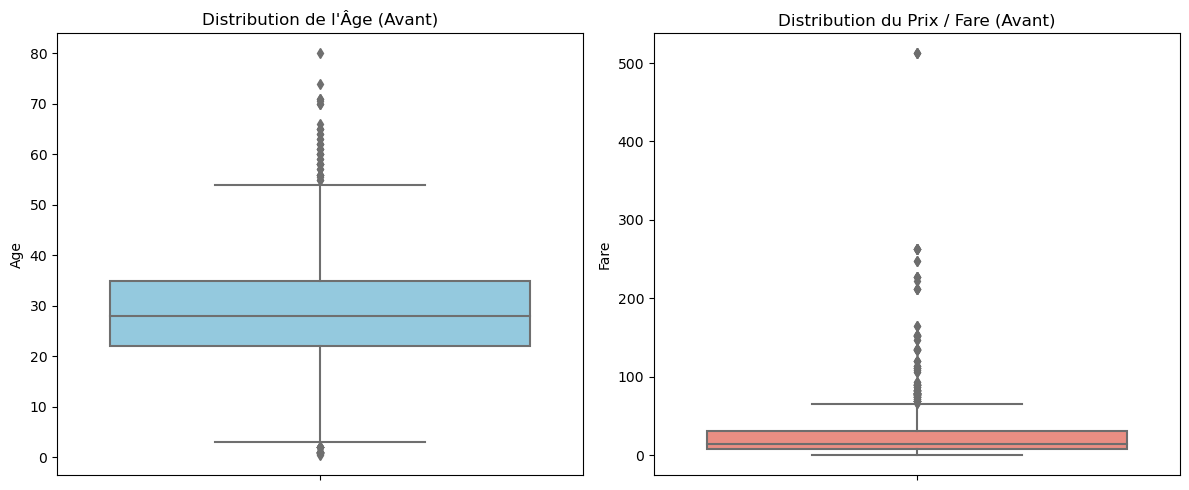

Nombre d'outliers détectés pour l'Âge (IQR) : 65
Nombre d'outliers détectés pour le Prix (Z-score > 3) : 20
--- COMPARAISON DES STATISTIQUES ---
Dimensions initiales : (889, 17)
Dimensions après suppression des outliers d'âge : (824, 17)

Évolution de la colonne 'Fare' (Prix) :
 - Maximum initial : 512.3292 $
 - Maximum après Plafonnement (98%) : 211.3375 $
 - Maximum après Transformation Log : 6.24


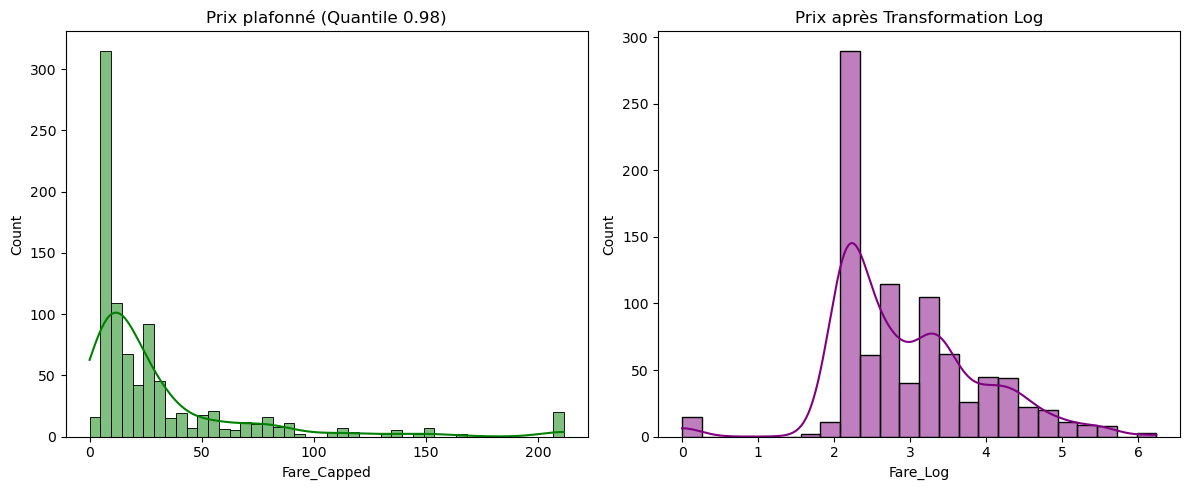

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration des graphiques
plt.figure(figsize=(12, 5))

# Boxplot pour l'Âge
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'], color='skyblue')
plt.title("Distribution de l'Âge (Avant)")

# Boxplot pour le Prix (Fare)
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'], color='salmon')
plt.title("Distribution du Prix / Fare (Avant)")

plt.tight_layout()
plt.show()


# Calcul du IQR pour l'Âge
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

limite_inf_age = Q1 - 1.5 * IQR
limite_sup_age = Q3 + 1.5 * IQR

outliers_age = df[(df['Age'] < limite_inf_age) | (df['Age'] > limite_sup_age)]
print(f"Nombre d'outliers détectés pour l'Âge (IQR) : {len(outliers_age)}")

# Calcul du score Z pour Fare
z_scores_fare = np.abs(stats.zscore(df['Fare']))
outliers_fare_z = df[z_scores_fare > 3]

print(f"Nombre d'outliers détectés pour le Prix (Z-score > 3) : {len(outliers_fare_z)}")

# Déterminer le seuil empirique au quantile 98%
seuil_98 = df['Fare'].quantile(0.98)

# Plafonner les valeurs supérieures au seuil
df['Fare_Capped'] = np.where(df['Fare'] > seuil_98, seuil_98, df['Fare'])

df['Fare_Log'] = np.log1p(df['Fare'])

# Filtrer le DataFrame pour ne garder que l'intérieur des bornes IQR de l'âge
df_cleaned = df[(df['Age'] >= limite_inf_age) & (df['Age'] <= limite_sup_age)].copy()

print("--- COMPARAISON DES STATISTIQUES ---")
print(f"Dimensions initiales : {df.shape}")
print(f"Dimensions après suppression des outliers d'âge : {df_cleaned.shape}\n")

print("Évolution de la colonne 'Fare' (Prix) :")
print(f" - Maximum initial : {df['Fare'].max()} $")
print(f" - Maximum après Plafonnement (98%) : {df['Fare_Capped'].max()} $")
print(f" - Maximum après Transformation Log : {df['Fare_Log'].max():.2f}")

# Visualisation finale du Prix après traitement log et plafonnement
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Fare_Capped'], kde=True, color='green')
plt.title("Prix plafonné (Quantile 0.98)")

plt.subplot(1, 2, 2)
sns.histplot(df['Fare_Log'], kde=True, color='purple')
plt.title("Prix après Transformation Log")

plt.tight_layout()
plt.show()




In [ ]:
#exercice5

In [ ]:
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# 1. Sélectionner les caractéristiques à mettre à l'échelle
# 'Age' suit une distribution relativement normale (après traitement des outliers) -> StandardScaler
# 'Fare' (ou 'FamilySize') est asymétrique ou bornée -> MinMaxScaler

# Initialisation des outils de Scikit-Learn
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# 2. Application du StandardScaler (Moyenne = 0, Écart-type = 1)
# Adapté pour la colonne 'Age'
df_cleaned['Age_Scaled'] = standard_scaler.fit_transform(df_cleaned[['Age']])

# 3. Application du MinMaxScaler (Valeurs ramenées strictement entre 0 et 1)
# Adapté pour la colonne 'Fare' (Prix) afin de l'aligner sans déformer son asymétrie
df_cleaned['Fare_Scaled'] = minmax_scaler.fit_transform(df_cleaned[['Fare_Capped']])

# Optionnel : On peut aussi normaliser 'FamilySize' qui est une variable strictement bornée
df_cleaned['FamilySize_Scaled'] = minmax_scaler.fit_transform(df_cleaned[['FamilySize']])


# 4. Comparaison et vérification des résultats
print("--- VÉRIFICATION DES ÉCHELLES ---")
print("Statistiques pour 'Age' après StandardScaler :")
print(f" - Moyenne (proche de 0) : {df_cleaned['Age_Scaled'].mean():.2f}")
print(f" - Écart-type (égal à 1) : {df_cleaned['Age_Scaled'].std():.2f}\n")

print("Statistiques pour 'Fare' après MinMaxScaler :")
print(f" - Valeur minimale (égale à 0) : {df_cleaned['Fare_Scaled'].min()}")
print(f" - Valeur maximale (égale à 1) : {df_cleaned['Fare_Scaled'].max()}")



--- VÉRIFICATION DES ÉCHELLES ---
Statistiques pour 'Age' après StandardScaler :
 - Moyenne (proche de 0) : -0.00
 - Écart-type (égal à 1) : 1.00

Statistiques pour 'Fare' après MinMaxScaler :
 - Valeur minimale (égale à 0) : 0.0
 - Valeur maximale (égale à 1) : 1.0


In [ ]:
#exercice6


import pandas as pd
import os
from sklearn.preprocessing import OrdinalEncoder



# Étape A : Encodage One-Hot pour les variables nominales restantess
df_nominal = pd.get_dummies(df_cleaned[['Embarked', 'Title']], drop_first=True, dtype=int)

# Étape B : Encodage Ordinal pour la variable Pclass (CORRECTION DU BUG DE TRI)
ordinal_encoder = OrdinalEncoder() # Scikit-Learn gère automatiquement le tri croissant numérique [1, 2, 3]
pclass_encoded = ordinal_encoder.fit_transform(df_cleaned[['Pclass']])
df_ordinal = pd.DataFrame(pclass_encoded, columns=['Pclass_Ordinal'], index=df_cleaned.index)

# Étape C : Fusion finale et nettoyage des colonnes brutes d'origine
colonnes_a_supprimer = ['Embarked', 'Title', 'Pclass', 'Name', 'Ticket', 'Cabin', 'Age', 'Fare', 'Fare_Capped']
df_final = df_cleaned.drop(columns=colonnes_a_supprimer)
df_final


,PassengerId,Survived,SibSp,Parch,FamilySize,Title_Encoded,Sex_male,Fare_Log,Age_Scaled,Fare_Scaled,FamilySize_Scaled
0,1,0,1,0,2,2,1,2.110213,-0.639374,0.034305,0.1
1,2,1,1,0,2,3,0,4.280593,0.933589,0.337296,0.1
2,3,1,0,0,1,1,0,2.188856,-0.246133,0.037499,0.0
3,4,1,1,0,2,3,0,3.990834,0.638658,0.251257,0.1
4,5,0,0,0,1,2,1,2.202765,0.638658,0.038091,0.0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,0,0,1,4,1,2.639057,-0.147823,0.061513,0.0
887,888,1,0,0,1,1,0,3.433987,-0.934305,0.141953,0.0
888,889,0,1,2,4,1,0,3.196630,-0.049513,0.110960,0.3
889,890,1,0,0,1,2,1,3.433987,-0.246133,0.141953,0.0


In [ ]:
#exercice7

In [18]:

import pandas as pd

# 1. Définition des bornes des compartiments (bins) et des étiquettes associées
# [0, 12] -> Enfant | (12, 18] -> Adolescent | (18, 60] -> Adulte | (60, 100] -> Senior
bornes_age = [0, 12, 18, 60, 100]
categories_age = ['Enfant', 'Adolescent', 'Adulte', 'Senior']

# On applique pd.cut sur la colonne 'Age' d'origine du DataFrame nettoyé
df_cleaned['AgeGroup'] = pd.cut(df_cleaned['Age'], bins=bornes_age, labels=categories_age)


# 2. Application de l'encodage One-Hot sur ces tranches d'âge
# On utilise 'drop_first=True' pour éviter la redondance dans le modèle
df_age_nominal = pd.get_dummies(df_cleaned['AgeGroup'], prefix='Age', drop_first=True, dtype=int)


# 3. Fusion avec le jeu de données principal (df_final de l'exercice précédent)
# On supprime d'abord 'Age_Scaled' si vous préférez utiliser les tranches d'âge à la place
if 'Age_Scaled' in df_final.columns:
    df_final = df_final.drop(columns=['Age_Scaled'])

# Fusion finale des nouvelles colonnes binaires d'âge
df_final = pd.concat([df_final, df_age_nominal], axis=1)


# 4. Vérification du résultat
print("Répartition des passagers par tranche d'âge :")
print(df_cleaned['AgeGroup'].value_counts())
print("\nNouvelles colonnes ajoutées au jeu de données final :")
print(df_age_nominal.columns.tolist())


Répartition des passagers par tranche d'âge :
AgeGroup
Adulte        709
Adolescent     70
Enfant         45
Senior          0
Name: count, dtype: int64

Nouvelles colonnes ajoutées au jeu de données final :
['Age_Adolescent', 'Age_Adulte', 'Age_Senior']
